# mencari/Menghitung jarak dynamic Time Warping


---

## Mencari Jarak Suara Menggunakan DTW

Dalam sistem ini, proses pencocokan perintah suara dilakukan dengan membandingkan rekaman baru terhadap 51 contoh suara “tutup”. Metode yang dipakai adalah Dynamic Time Warping (DTW). Sebelum dihitung, setiap rekaman diubah menjadi ciri akustik berupa MFCC. Fitur MFCC dipilih karena lebih stabil dalam mewakili karakter suara dibandingkan memakai sinyal audio mentah.

Setiap rekaman tentu memiliki durasi yang tidak selalu sama. Karena itu, DTW berperan untuk menyesuaikan perbedaan panjang waktu antara MFCC rekaman baru dan MFCC setiap sampel. Dari proses tersebut muncul nilai jarak untuk masing-masing perbandingan. Semakin kecil jarak yang dihasilkan, semakin tinggi tingkat kemiripannya.

Setelah semua sampel selesai dibandingkan, sistem akan mengambil nilai jarak paling kecil sebagai hasil akhir. Nilai inilah yang menunjukkan contoh suara “tutup” yang paling mendekati rekaman terbaru. Berdasarkan nilai tersebut, sistem dapat menentukan apakah perintah yang diberikan termasuk kategori “tutup”.

---

## Dynamic Time Warping (DTW)

Dynamic Time Warping adalah metode yang digunakan untuk mengukur kemiripan dua sinyal deret waktu yang panjangnya tidak sama. Dalam konteks pengenalan suara, DTW membantu menyelaraskan pola akustik dari dua rekaman meskipun kecepatan atau tempo pengucapannya berbeda.

DTW bekerja dengan mencari jalur penyelarasan terbaik antara dua rangkaian fitur, misalnya MFCC dari sampel dan MFCC dari audio input. Jalur penyelarasan ini dipilih untuk menghasilkan total biaya (cost) paling rendah.

### Prinsip Kerja DTW

* Menghitung jarak lokal antara setiap pasangan fitur dari kedua sinyal.
* Membentuk matriks biaya kumulatif melalui teknik dynamic programming.
* Menentukan jalur optimal dalam matriks yang memberikan biaya total paling kecil.
* Mengambil nilai akhir sebagai hasil jarak DTW.

Semakin kecil nilai jarak DTW, semakin mirip pola suara yang dibandingkan.

---




In [1]:
import os
import numpy as np
import librosa
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

In [2]:
# STEP 1: LOAD + TRIM + NORMALIZE
import os
import librosa
import numpy as np

audio_path = "suara/Rekaman/Recording_121.wav"
assert os.path.exists(audio_path), f"File tidak ditemukan: {audio_path}"

y, sr = librosa.load(audio_path, sr=None)   # sr=None supaya tak di-resample
print("SR:", sr, "samples:", y.shape[0], "durasi(s):", librosa.get_duration(y=y, sr=sr))

# Trim silence di kedua ujung
y_trimmed, _ = librosa.effects.trim(y, top_db=20)
# Cegah pembagian 0
if np.max(np.abs(y_trimmed)) == 0:
    raise ValueError("Audio terpotong jadi nol setelah trim — cek file.")
y_norm = y_trimmed / np.max(np.abs(y_trimmed))

print("Durasi setelah trim:", librosa.get_duration(y=y_norm, sr=sr))


SR: 44100 samples: 102528 durasi(s): 2.3248979591836734


Durasi setelah trim: 0.4876190476190476


In [3]:
# STEP 2: MFCC
n_mfcc = 13
mfcc = librosa.feature.mfcc(y=y_norm, sr=sr, n_mfcc=n_mfcc)  # shape = (n_mfcc, frames)
print("MFCC shape:", mfcc.shape)
# Transpose agar jadi (frames, features)
mfcc_T = mfcc.T


MFCC shape: (13, 43)


In [4]:
# STEP 3: DTW helper
import librosa
import numpy as np

def compute_dtw(mfccA, mfccB, metric='euclidean'):
    # mfccA, mfccB: (frames, features)
    # transpos ke shape (features, frames) untuk librosa.sequence.dtw
    A = mfccA.T
    B = mfccB.T
    # Hitung cost matrix (pairwise Euclidean)
    # librosa.sequence.dtw menerima input (features, frames)
    D, wp = librosa.sequence.dtw(X=A, Y=B, metric=metric)  # D: cumulative cost matrix, wp: warping path
    # total distance di titik akhir (norm atau total cost)
    total_cost = D[-1, -1]
    return D, wp, total_cost


In [5]:
# STEP 4: compare with a single sample
sample_path = "sample.wav"   # ganti sesuai nama file
y_s, sr_s = librosa.load(sample_path, sr=sr)   # pakai sr sama agar konsisten
y_s_trim, _ = librosa.effects.trim(y_s, top_db=20)
y_s_norm = y_s_trim / np.max(np.abs(y_s_trim))
mfcc_s = librosa.feature.mfcc(y=y_s_norm, sr=sr, n_mfcc=n_mfcc).T

D, wp, cost = compute_dtw(mfcc_T, mfcc_s)
print("DTW total cost:", cost)
print("Warp path length:", len(wp))


DTW total cost: 2380.856904028373
Warp path length: 43


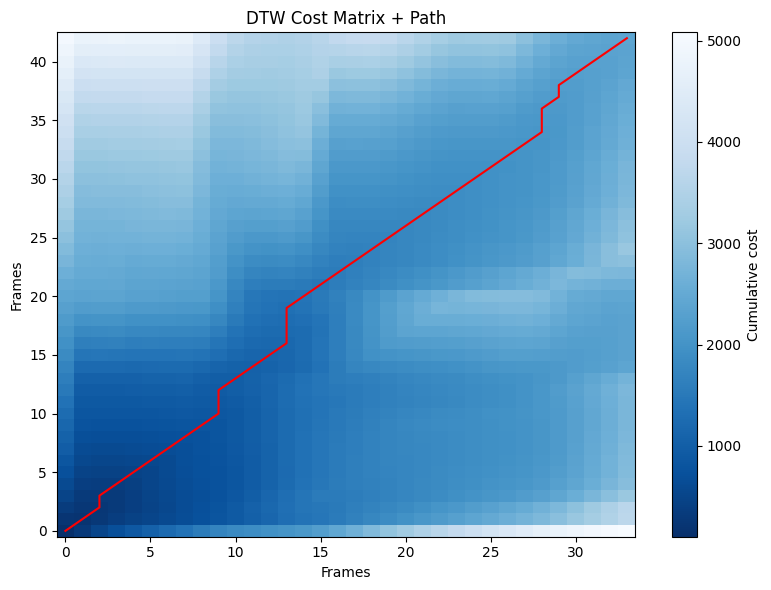

In [6]:
# STEP 5: plot cost matrix + warp path (mirip halaman contoh)
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

plt.figure(figsize=(8,6))
librosa.display.specshow(D, x_axis='frames', y_axis='frames', cmap='Blues_r')
wp_arr = np.array(wp)
plt.plot(wp_arr[:,1], wp_arr[:,0], color='red', linewidth=1.5)  # note: axis order
plt.title("DTW Cost Matrix + Path")
plt.colorbar(label='Cumulative cost')
plt.tight_layout()
plt.show()


In [7]:
out = "out/dtw_matrix.png"
os.makedirs("out", exist_ok=True)
plt.savefig(out, dpi=150)


<Figure size 640x480 with 0 Axes>

C:\Users\Jordan\AppData\Local\Temp\ipykernel_17776\94866767.py:9: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2,1,1)


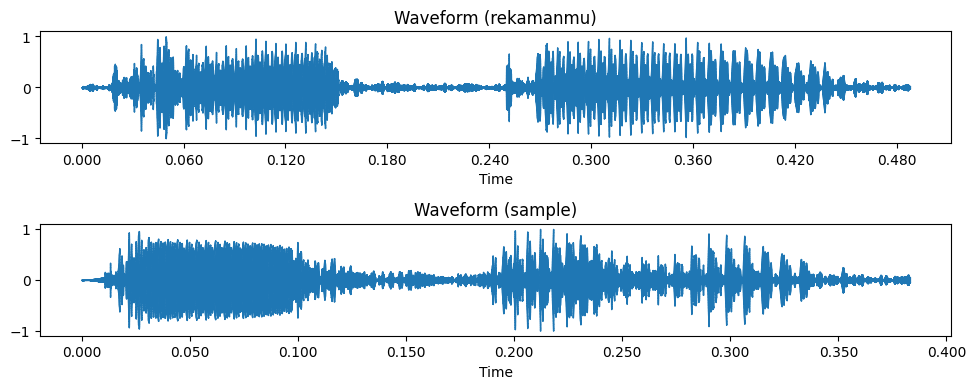

In [8]:
# STEP 6: visualisasi alignment (garis antar frame) + waveform
plt.figure(figsize=(10,4))
# Plot beberapa garis penghubung (sampling agar tidak penuh)
sample_step = max(1, int(len(wp)/400))
for (i,j) in wp[::sample_step]:
    plt.plot([i, j], [0, 0], color='skyblue', alpha=0.25)  # sederhana: hanya ilustrasi

# Sambil juga tampilkan waveform rekaman (opsional)
plt.subplot(2,1,1)
librosa.display.waveshow(y_norm, sr=sr)
plt.title("Waveform (rekamanmu)")

plt.subplot(2,1,2)
librosa.display.waveshow(y_s_norm, sr=sr)
plt.title("Waveform (sample)")

plt.tight_layout()
plt.show()


In [9]:
# STEP 7: compare with all samples and choose smallest distance
import glob

sample_files = sorted(glob.glob("sample.wav"))
results = []
for f in sample_files:
    ys, _ = librosa.load(f, sr=sr)
    ys_trim, _ = librosa.effects.trim(ys, top_db=20)
    ys_norm = ys_trim / np.max(np.abs(ys_trim))
    mfcc_s = librosa.feature.mfcc(y=ys_norm, sr=sr, n_mfcc=n_mfcc).T
    D, wp, cost = compute_dtw(mfcc_T, mfcc_s)
    results.append((f, cost))

# sort by cost (lebih kecil = lebih mirip)
results_sorted = sorted(results, key=lambda x: x[1])
for f,c in results_sorted[:5]:
    print(f, c)

best_file, best_cost = results_sorted[0]
print("Most similar sample:", best_file, "distance:", best_cost)


sample.wav 2380.856904028373
Most similar sample: sample.wav distance: 2380.856904028373
